In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import os



data_path = r"C:\workspace\NaverBoostCamp\Book Rating Prediction\data"
users = pd.read_csv(os.path.join(data_path, 'users.csv'))
users = pd.read_csv(os.path.join(data_path, 'users.csv'))
books = pd.read_csv(os.path.join(data_path, 'books.csv'))
interactions = pd.read_csv(os.path.join(data_path, 'train_ratings.csv'))

print(f"Users: {len(users)}")
print(f"Books: {len(books)}")
print(f"Interactions: {len(interactions)}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === 2. 조인 ===
df = interactions.merge(books[['isbn', 'book_author']], on='isbn', how='left')

# 유저당 아이템(책) 수
user_item_counts = df.groupby('user_id')['isbn'].nunique()
print("=== Items per User ===")
print(user_item_counts.describe())
print("\nTop 5:")
print(user_item_counts.nlargest(5))
print("\n1~5 Distribution:")
for i in range(1, 6):
    count = (user_item_counts == i).sum()
    pct = count / len(user_item_counts) * 100
    print(f"  {i}: {count:,} ({pct:.2f}%)")

# ISBN당 유저 수
isbn_user_counts = df.groupby('isbn')['user_id'].nunique()
print("\n=== Users per ISBN ===")
print(isbn_user_counts.describe())
print("\nTop 5:")
print(isbn_user_counts.nlargest(5))
print("\n1~5 Distribution:")
for i in range(1, 6):
    count = (isbn_user_counts == i).sum()
    pct = count / len(isbn_user_counts) * 100
    print(f"  {i}: {count:,} ({pct:.2f}%)")

# Author당 아이템(책) 수
author_item_counts = df.groupby('book_author')['isbn'].nunique()
print("\n=== Items per Author ===")
print(author_item_counts.describe())
print("\nTop 5:")
print(author_item_counts.nlargest(5))
print("\n1~5 Distribution:")
for i in range(1, 6):
    count = (author_item_counts == i).sum()
    pct = count / len(author_item_counts) * 100
    print(f"  {i}: {count:,} ({pct:.2f}%)")

# Author당 interaction 수
author_interaction_counts = df.groupby('book_author').size()
print("\n=== Interactions per Author ===")
print(author_interaction_counts.describe())
print("\nTop 5:")
print(author_interaction_counts.nlargest(5))
print("\n1~5 Distribution:")
for i in range(1, 6):
    count = (author_interaction_counts == i).sum()
    pct = count / len(author_interaction_counts) * 100
    print(f"  {i}: {count:,} ({pct:.2f}%)")

# === 원형 그래프 (1~5, 6+) ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Items per User
user_pie_data = []
user_pie_labels = []
for i in range(1, 6):
    count = (user_item_counts == i).sum()
    user_pie_data.append(count)
    user_pie_labels.append(f'{i}')
user_pie_data.append((user_item_counts >= 6).sum())
user_pie_labels.append('6+')

axes[0, 0].pie(user_pie_data, labels=user_pie_labels, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Items per User Distribution')

# Users per ISBN
isbn_pie_data = []
isbn_pie_labels = []
for i in range(1, 6):
    count = (isbn_user_counts == i).sum()
    isbn_pie_data.append(count)
    isbn_pie_labels.append(f'{i}')
isbn_pie_data.append((isbn_user_counts >= 6).sum())
isbn_pie_labels.append('6+')

axes[0, 1].pie(isbn_pie_data, labels=isbn_pie_labels, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Users per ISBN Distribution')

# Items per Author (책 개수 - 다작)
author_items_pie_data = []
author_items_pie_labels = []
for i in range(1, 6):
    count = (author_item_counts == i).sum()
    author_items_pie_data.append(count)
    author_items_pie_labels.append(f'{i}')
author_items_pie_data.append((author_item_counts >= 6).sum())
author_items_pie_labels.append('6+')

axes[1, 0].pie(author_items_pie_data, labels=author_items_pie_labels, autopct='%1.1f%%', startangle=90)
axes[1, 0].set_title('Items per Author (Book Count)')

# Interactions per Author (읽힌 수 - 베스트셀러)
author_int_pie_data = []
author_int_pie_labels = []
for i in range(1, 6):
    count = (author_interaction_counts == i).sum()
    author_int_pie_data.append(count)
    author_int_pie_labels.append(f'{i}')
author_int_pie_data.append((author_interaction_counts >= 6).sum())
author_int_pie_labels.append('6+')

axes[1, 1].pie(author_int_pie_data, labels=author_int_pie_labels, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title('Interactions per Author (Bestsellers)')

plt.tight_layout()
plt.show()

# === 6 이상 분포 (x축만 log2 scale, y축은 선형) ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Items per User (6+)
user_high = user_item_counts[user_item_counts >= 6]
user_high_counts = user_high.value_counts().sort_index()
user_high_pct = (user_high_counts / len(user_item_counts) * 100)
axes[0, 0].scatter(user_high_pct.index, user_high_pct.values, s=50, alpha=0.7)
axes[0, 0].set_xlabel('Number of Items (log2 scale)')
axes[0, 0].set_ylabel('Percentage (%)')
axes[0, 0].set_title('Items per User (6+)')
axes[0, 0].set_xscale('log', base=2)
axes[0, 0].grid(True, alpha=0.3)

# Users per ISBN (6+)
isbn_high = isbn_user_counts[isbn_user_counts >= 6]
isbn_high_counts = isbn_high.value_counts().sort_index()
isbn_high_pct = (isbn_high_counts / len(isbn_user_counts) * 100)
axes[0, 1].scatter(isbn_high_pct.index, isbn_high_pct.values, s=50, alpha=0.7)
axes[0, 1].set_xlabel('Number of Users (log2 scale)')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Users per ISBN (6+)')
axes[0, 1].set_xscale('log', base=2)
axes[0, 1].grid(True, alpha=0.3)

# Items per Author (6+ - 책 개수)
author_items_high = author_item_counts[author_item_counts >= 6]
author_items_high_counts = author_items_high.value_counts().sort_index()
author_items_high_pct = (author_items_high_counts / len(author_item_counts) * 100)
axes[1, 0].scatter(author_items_high_pct.index, author_items_high_pct.values, s=50, alpha=0.7)
axes[1, 0].set_xlabel('Number of Items (log2 scale)')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].set_title('Items per Author (6+ books)')
axes[1, 0].set_xscale('log', base=2)
axes[1, 0].grid(True, alpha=0.3)

# Interactions per Author (6+ - 읽힌 수)
author_int_high = author_interaction_counts[author_interaction_counts >= 6]
author_int_high_counts = author_int_high.value_counts().sort_index()
author_int_high_pct = (author_int_high_counts / len(author_interaction_counts) * 100)
axes[1, 1].scatter(author_int_high_pct.index, author_int_high_pct.values, s=50, alpha=0.7)
axes[1, 1].set_xlabel('Number of Interactions (log2 scale)')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].set_title('Interactions per Author (6+ reads)')
axes[1, 1].set_xscale('log', base=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# === 데이터 집중도 분석 ===
print("\n" + "="*80)
print("데이터 집중도 분석 (Concentration Analysis)")
print("="*80)

# 전체 interaction 수
total_interactions = len(df)

# 1. 유저별 interaction 수
user_interaction_counts = df.groupby('user_id').size().sort_values(ascending=False)
user_cumsum = user_interaction_counts.cumsum()
user_cumsum_pct = (user_cumsum / total_interactions * 100)

print("\n=== Users (많은 책을 읽은 유저) ===")
for pct in [1, 5, 10, 20, 50]:
    n_users = int(len(user_interaction_counts) * pct / 100)
    if n_users > 0:
        interaction_pct = user_cumsum_pct.iloc[n_users-1]
        top_users = user_interaction_counts.head(n_users)
        avg_interactions = top_users.mean()
        min_interactions = top_users.min()
        avg_items = user_item_counts[top_users.index].mean()
        min_items = user_item_counts[top_users.index].min()
        print(f"상위 {pct:>2}% 유저 ({n_users:>6}명) → 전체 interaction의 {interaction_pct:>5.2f}% | "
              f"평균 {avg_interactions:>5.1f}개 (최소 {min_interactions:>3}개) interaction, "
              f"평균 {avg_items:>5.1f}권 (최소 {min_items:>3}권) 읽음")

# 2. ISBN별 interaction 수
isbn_interaction_counts = df.groupby('isbn').size().sort_values(ascending=False)
isbn_cumsum = isbn_interaction_counts.cumsum()
isbn_cumsum_pct = (isbn_cumsum / total_interactions * 100)

print("\n=== Books (많은 유저를 가진 책) ===")
for pct in [1, 5, 10, 20, 50]:
    n_books = int(len(isbn_interaction_counts) * pct / 100)
    if n_books > 0:
        interaction_pct = isbn_cumsum_pct.iloc[n_books-1]
        top_books = isbn_interaction_counts.head(n_books)
        avg_interactions = top_books.mean()
        min_interactions = top_books.min()
        avg_users = isbn_user_counts[top_books.index].mean()
        min_users = isbn_user_counts[top_books.index].min()
        print(f"상위 {pct:>2}% 책 ({n_books:>6}권) → 전체 interaction의 {interaction_pct:>5.2f}% | "
              f"평균 {avg_interactions:>5.1f}개 (최소 {min_interactions:>3}개) interaction, "
              f"평균 {avg_users:>5.1f}명 (최소 {min_users:>3}명)이 읽음")

# 3-1. 저자별 interaction 수 (많이 읽힌 저자)
author_interaction_counts = df.groupby('book_author').size().sort_values(ascending=False)
author_cumsum = author_interaction_counts.cumsum()
author_cumsum_pct = (author_cumsum / total_interactions * 100)

print("\n=== Authors - By Interactions (많이 읽힌 저자 - 베스트셀러) ===")
for pct in [1, 5, 10, 20, 50]:
    n_authors = int(len(author_interaction_counts) * pct / 100)
    if n_authors > 0:
        interaction_pct = author_cumsum_pct.iloc[n_authors-1]
        top_authors = author_interaction_counts.head(n_authors)
        avg_interactions = top_authors.mean()
        min_interactions = top_authors.min()
        avg_items = author_item_counts[top_authors.index].mean()
        min_items = author_item_counts[top_authors.index].min()

        # 책당 평균 읽힌 횟수
        reads_per_book = top_authors / author_item_counts[top_authors.index]
        avg_reads_per_book = reads_per_book.mean()

        print(f"상위 {pct:>2}% 저자 ({n_authors:>6}명) → 전체 interaction의 {interaction_pct:>5.2f}% | "
              f"평균 {avg_items:>5.1f}권 (최소 {min_items:>3}권) 씀, "
              f"책당 평균 {avg_reads_per_book:>5.1f}번 읽힘")

# 3-2. 저자별 책 개수 (많이 쓴 저자)
author_items_sorted = author_item_counts.sort_values(ascending=False)
# 책 개수로 정렬된 저자들의 interaction 합계
author_items_cumsum_interactions = []
cumsum_interactions = 0
for author in author_items_sorted.index:
    cumsum_interactions += author_interaction_counts[author]
    author_items_cumsum_interactions.append(cumsum_interactions)

author_items_cumsum_pct = [(x / total_interactions * 100) for x in author_items_cumsum_interactions]

print("\n=== Authors - By Book Count (많은 책을 쓴 저자 - 다작) ===")
for pct in [1, 5, 10, 20, 50]:
    n_authors = int(len(author_items_sorted) * pct / 100)
    if n_authors > 0:
        interaction_pct = author_items_cumsum_pct[n_authors-1]
        top_authors_by_items = author_items_sorted.head(n_authors)
        avg_items = top_authors_by_items.mean()
        min_items = top_authors_by_items.min()

        # 책당 평균 읽힌 횟수 계산
        interactions_per_book = author_interaction_counts[top_authors_by_items.index] / author_item_counts[top_authors_by_items.index]
        avg_reads_per_book = interactions_per_book.mean()

        print(f"상위 {pct:>2}% 저자 ({n_authors:>6}명) → 전체 interaction의 {interaction_pct:>5.2f}% | "
              f"평균 {avg_items:>5.1f}권 (최소 {min_items:>3}권) 씀, "
              f"책당 평균 {avg_reads_per_book:>5.1f}번 읽힘")

# === 누적 분포 그래프 ===
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Users
user_pct = np.arange(1, len(user_cumsum_pct) + 1) / len(user_cumsum_pct) * 100
axes[0, 0].plot(user_pct, user_cumsum_pct.values, linewidth=2)
axes[0, 0].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect equality')
axes[0, 0].set_xlabel('Top X% of Users')
axes[0, 0].set_ylabel('Cumulative % of Interactions')
axes[0, 0].set_title('User Concentration Curve')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, 100)
axes[0, 0].set_ylim(0, 100)

# Books
book_pct = np.arange(1, len(isbn_cumsum_pct) + 1) / len(isbn_cumsum_pct) * 100
axes[0, 1].plot(book_pct, isbn_cumsum_pct.values, linewidth=2)
axes[0, 1].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect equality')
axes[0, 1].set_xlabel('Top X% of Books')
axes[0, 1].set_ylabel('Cumulative % of Interactions')
axes[0, 1].set_title('Book Concentration Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, 100)
axes[0, 1].set_ylim(0, 100)

# Authors - By Interactions
author_pct = np.arange(1, len(author_cumsum_pct) + 1) / len(author_cumsum_pct) * 100
axes[1, 0].plot(author_pct, author_cumsum_pct.values, linewidth=2)
axes[1, 0].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect equality')
axes[1, 0].set_xlabel('Top X% of Authors (by interactions)')
axes[1, 0].set_ylabel('Cumulative % of Interactions')
axes[1, 0].set_title('Author Concentration - By Interactions')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, 100)
axes[1, 0].set_ylim(0, 100)

# Authors - By Book Count
author_items_pct = np.arange(1, len(author_items_cumsum_pct) + 1) / len(author_items_cumsum_pct) * 100
axes[1, 1].plot(author_items_pct, author_items_cumsum_pct, linewidth=2)
axes[1, 1].plot([0, 100], [0, 100], 'r--', alpha=0.5, label='Perfect equality')
axes[1, 1].set_xlabel('Top X% of Authors (by book count)')
axes[1, 1].set_ylabel('Cumulative % of Interactions')
axes[1, 1].set_title('Author Concentration - By Book Count')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 100)
axes[1, 1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# === 1~5개만 가진 경우가 전체 interaction에서 차지하는 비율 ===
print("\n" + "="*80)
print("전체 interaction 중 1~5개만 가진 경우의 비율")
print("="*80)

# Users
print("\n=== Users (n개만 읽은 유저들의 interaction) ===")
for i in range(1, 6):
    users_with_i = user_interaction_counts[user_interaction_counts == i]
    total_interactions_from_i = users_with_i.sum()  # i개씩 읽은 유저들의 총 interaction
    pct = total_interactions_from_i / total_interactions * 100
    print(f"{i}개만 읽은 유저들의 interaction: {total_interactions_from_i:>8}개 ({pct:>5.2f}%)")

# Books
print("\n=== Books (n명만 읽은 책들의 interaction) ===")
for i in range(1, 6):
    books_with_i = isbn_interaction_counts[isbn_interaction_counts == i]
    total_interactions_from_i = books_with_i.sum()
    pct = total_interactions_from_i / total_interactions * 100
    print(f"{i}명만 읽은 책들의 interaction: {total_interactions_from_i:>8}개 ({pct:>5.2f}%)")

# Authors - By Interactions (n개 interaction만 가진 저자)
print("\n=== Authors - By Interactions (n개 interaction만 가진 저자) ===")
for i in range(1, 6):
    authors_with_i = author_interaction_counts[author_interaction_counts == i]
    total_interactions_from_i = authors_with_i.sum()
    pct = total_interactions_from_i / total_interactions * 100
    print(f"{i}개 interaction만 가진 저자들: {total_interactions_from_i:>8}개 ({pct:>5.2f}%)")

# Authors - By Book Count (n권만 쓴 저자)
print("\n=== Authors - By Book Count (n권만 쓴 저자) ===")
for i in range(1, 6):
    authors_with_i_books = author_item_counts[author_item_counts == i]
    # 이 저자들의 총 interaction 계산
    total_interactions_from_i = sum(author_interaction_counts[author] for author in authors_with_i_books.index)
    pct = total_interactions_from_i / total_interactions * 100
    print(f"{i}권만 쓴 저자들의 interaction: {total_interactions_from_i:>8}개 ({pct:>5.2f}%)")

In [ ]:
# === Interaction당 기댓값 (랜덤 뽑을 때) ===
print("\n" + "="*80)
print("Interaction에서 랜덤 뽑을 때 기댓값")
print("="*80)

# Users
weighted_mean_user = 0
user_count_distribution = user_interaction_counts.value_counts()  # 각 count별 유저 수
for count, freq in user_count_distribution.items():
    # count개 읽은 유저가 freq명 있음 → 총 count*freq개 interaction 생성
    prob = (count * freq) / total_interactions  # 이 유저들의 interaction이 뽑힐 확률
    weighted_mean_user += count * prob  # 기댓값에 기여

print("\n=== Users ===")
print(f"단순 평균 (유저당 평균): {user_item_counts.mean():.4f}개")
print(f"가중 평균 (interaction 뽑을 때): {weighted_mean_user:.4f}개")
print(f"→ 랜덤 interaction 하나 뽑으면, 그 유저는 평균 {weighted_mean_user:.2f}개 interaction 가짐")

# Books
weighted_mean_book = 0
isbn_count_distribution = isbn_interaction_counts.value_counts()
for count, freq in isbn_count_distribution.items():
    prob = (count * freq) / total_interactions
    weighted_mean_book += count * prob

print("\n=== Books ===")
print(f"단순 평균 (책당 평균): {isbn_user_counts.mean():.4f}명")
print(f"가중 평균 (interaction 뽑을 때): {weighted_mean_book:.4f}명")
print(f"→ 랜덤 interaction 하나 뽑으면, 그 책은 평균 {weighted_mean_book:.2f}개 interaction 가짐")

# Authors - By Interactions (많이 읽힌)
weighted_mean_author_int = 0
author_count_distribution = author_interaction_counts.value_counts()
for count, freq in author_count_distribution.items():
    prob = (count * freq) / total_interactions
    weighted_mean_author_int += count * prob

print("\n=== Authors - By Interactions (많이 읽힌) ===")
print(f"단순 평균 (저자당 interaction 평균): {author_interaction_counts.mean():.4f}개")
print(f"가중 평균 (interaction 뽑을 때): {weighted_mean_author_int:.4f}개")
print(f"→ 랜덤 interaction 하나 뽑으면, 그 저자는 평균 {weighted_mean_author_int:.2f}개 interaction 가짐")

# Authors - By Book Count (많이 쓴)
weighted_mean_author_books = 0
# interaction 기준으로 가중 평균 (각 interaction에서 저자가 쓴 책 개수)
for author in author_interaction_counts.index:
    int_count = author_interaction_counts[author]
    book_count = author_item_counts[author]
    prob = int_count / total_interactions
    weighted_mean_author_books += book_count * prob

print("\n=== Authors - By Book Count (책 개수) ===")
print(f"단순 평균 (저자당 책 평균): {author_item_counts.mean():.4f}권")
print(f"가중 평균 (interaction 뽑을 때): {weighted_mean_author_books:.4f}권")
print(f"→ 랜덤 interaction 하나 뽑으면, 그 저자는 평균 {weighted_mean_author_books:.2f}권 씀")

In [ ]:
# === 각 Interaction의 총 관련 Interaction 계산 ===
print("\n" + "="*80)
print("각 Interaction의 (User + Item + Author) Interaction 합 분석")
print("="*80)

# NaN 제거
df_clean = df.dropna(subset=['book_author'])
print(f"NaN 제거 전: {len(df):,}개")
print(f"NaN 제거 후: {len(df_clean):,}개")

# 각 interaction마다 관련된 총 interaction 계산
total_related_interactions = []

for idx, row in df_clean.iterrows():
    user_id = row['user_id']
    isbn = row['isbn']
    author = row['book_author']

    # 각각의 interaction 개수
    user_int = user_interaction_counts[user_id]
    item_int = isbn_interaction_counts[isbn]
    author_int = author_interaction_counts[author]

    # 합계
    total = user_int + item_int + author_int
    total_related_interactions.append(total)

# 정렬 (내림차순)
total_related_sorted = sorted(total_related_interactions, reverse=True)

# 역 누적 확률 (X 이상인 비율)
reverse_cumulative_prob = 100 - (np.arange(1, len(total_related_sorted) + 1) / len(total_related_sorted) * 100)

print(f"\n총 interaction 수: {len(total_related_interactions):,}개")
print(f"평균 (User + Item + Author) 합: {np.mean(total_related_interactions):.2f}")
print(f"중앙값: {np.median(total_related_interactions):.2f}")
print(f"최솟값: {min(total_related_interactions):,}")
print(f"최댓값: {max(total_related_interactions):,}")

# === 역 누적 분포 그래프 (CCDF) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 전체 분포 (x축만 로그 스케일)
axes[0].plot(total_related_sorted, reverse_cumulative_prob, linewidth=2)
axes[0].set_xlabel('Total Related Interactions (log scale)')
axes[0].set_ylabel('Probability >= X (%)')
axes[0].set_title('CCDF: Probability of Having X or More Related Interactions')
axes[0].set_xscale('log')
axes[0].set_ylim(0, 100)
axes[0].grid(True, alpha=0.3)

# === 하위 10% 상세 분석 ===
print("\n" + "="*80)
print("하위 10% Interaction 상세 분석")
print("="*80)

# 하위 10% 추출
bottom_10_idx = int(len(total_related_sorted) * 0.9)
bottom_10_values = total_related_sorted[bottom_10_idx:]
bottom_10_probs = reverse_cumulative_prob[bottom_10_idx:]

# 각 값별로 집계
from collections import Counter
value_counts = Counter(bottom_10_values)

print(f"\n하위 10% 구간: {len(bottom_10_values):,}개 interaction")
print(f"값 범위: {min(bottom_10_values)} ~ {max(bottom_10_values)}")
print(f"\n{'Total Related':>15} | {'개수':>10} | {'누적 %':>10} | {'>=X %':>10}")
print("-" * 80)

cumsum = 0
for value in sorted(value_counts.keys()):
    count = value_counts[value]
    cumsum += count
    cumulative_pct = cumsum / len(total_related_interactions) * 100
    ge_pct = (len(total_related_interactions) - (bottom_10_idx + cumsum)) / len(total_related_interactions) * 100

    print(f"{value:>15} | {count:>10,} | {cumulative_pct:>9.4f}% | {ge_pct:>9.4f}%")

print("-" * 80)
print(f"{'합계':>15} | {len(bottom_10_values):>10,} | {len(bottom_10_values)/len(total_related_interactions)*100:>9.2f}%")

plt.tight_layout()
plt.show()


평점별 Interaction 개수 분석

    평점 |         개수 |       비율
----------------------------------------
     1 |     13,249 |    4.32%
     2 |     12,929 |    4.21%
     3 |     10,520 |    3.43%
     4 |     12,707 |    4.14%
     5 |     14,111 |    4.60%
     6 |     25,311 |    8.25%
     7 |     52,928 |   17.25%
     8 |     73,593 |   23.99%
     9 |     48,673 |   15.86%
    10 |     42,774 |   13.94%
----------------------------------------
    합계 |    306,795 |  100.00%

평균 평점: 7.070
중앙값: 8.0
표준편차: 2.433


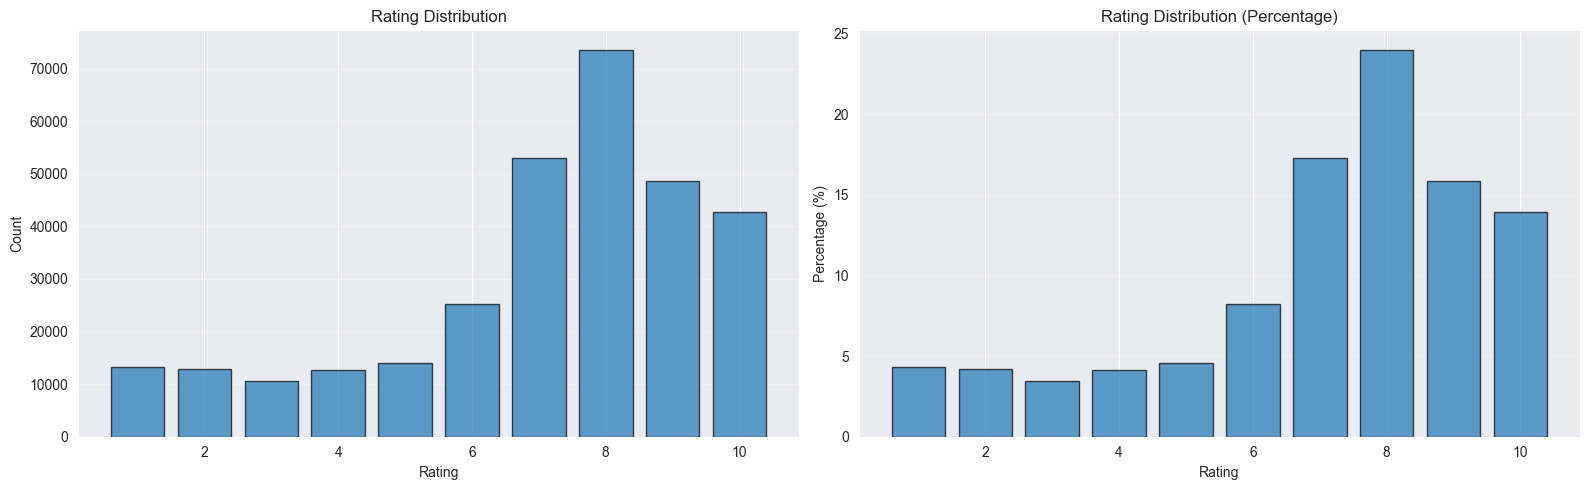

In [51]:
# === 평점별 상호작용 개수 ===
print("\n" + "="*80)
print("평점별 Interaction 개수 분석")
print("="*80)

# 평점별 개수
rating_counts = df['rating'].value_counts().sort_index()

print(f"\n{'평점':>6} | {'개수':>10} | {'비율':>8}")
print("-" * 40)
for rating, count in rating_counts.items():
    pct = count / len(df) * 100
    print(f"{rating:>6} | {count:>10,} | {pct:>7.2f}%")
print("-" * 40)
print(f"{'합계':>6} | {len(df):>10,} | {100.0:>7.2f}%")

print(f"\n평균 평점: {df['rating'].mean():.3f}")
print(f"중앙값: {df['rating'].median():.1f}")
print(f"표준편차: {df['rating'].std():.3f}")

# === 평점 분포 그래프 ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 막대 그래프
axes[0].bar(rating_counts.index, rating_counts.values, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Rating Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

# 비율 그래프
rating_pct = (rating_counts / len(df) * 100)
axes[1].bar(rating_pct.index, rating_pct.values, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Rating Distribution (Percentage)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()